
# Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


# 1

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


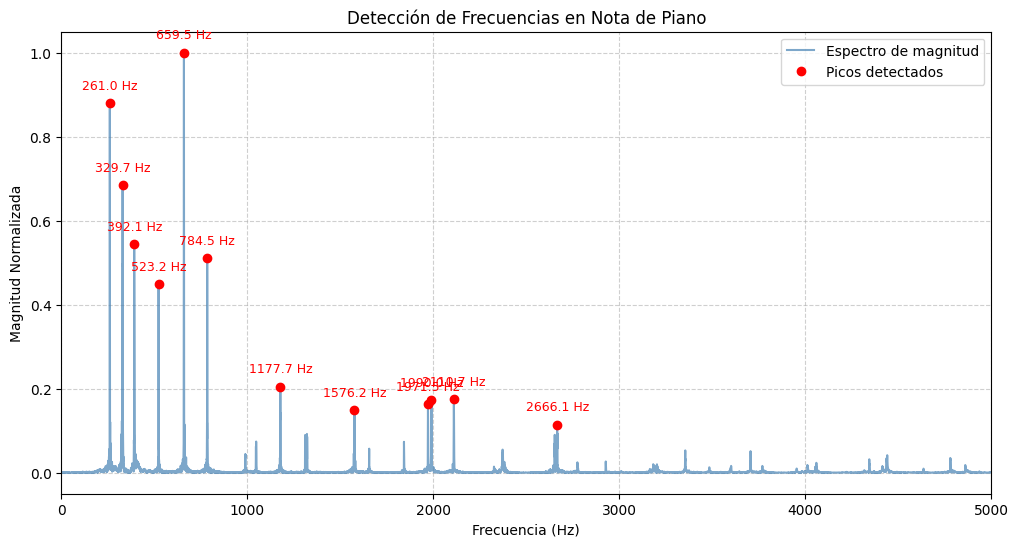

Frecuencias detectadas (Hz):
[ 261.00852273  329.74076705  392.09280303  523.17708333  659.48153409
  784.47561553 1177.72845644 1576.2014678  1971.484375   1990.04498106
 2110.68892045 2666.05705492]


In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# 1. Cargar audio
signal, sr = librosa.load(r"C:\Proyectos\Fisica-com\Fisica_Computacional_1\Sesiones\Fourier\Nota_CM_piano.mp3", sr=None) # hay que cambiar la ruta a donde apunte el archivo en el local.

# 2. Calcular FFT real
N = len(signal)
tf_magnitude = np.abs(np.fft.rfft(signal))
frecuencias = np.fft.rfftfreq(N, d=1/sr)

# 3. Normalizar la magnitud (opcional, para facilitar el umbral de detección)
tf_magnitude = tf_magnitude / np.max(tf_magnitude)

# 4. Detectar picos
# 'height' define la intensidad mínima (ej. 0.1 del máximo)
# 'distance' evita detectar múltiples puntos en un mismo pico ancho
peaks, properties = find_peaks(tf_magnitude, height=0.1, distance=20)

# 5. Visualización
plt.figure(figsize=(12, 6))
plt.plot(frecuencias, tf_magnitude, label="Espectro de magnitud", color='steelblue', alpha=0.7)

# Graficar los picos encontrados
plt.plot(frecuencias[peaks], tf_magnitude[peaks], "ro", label="Picos detectados")

# Anotar la frecuencia en cada pico
for i, peak_idx in enumerate(peaks):
    freq = frecuencias[peak_idx]
    plt.annotate(f"{freq:.1f} Hz", 
                 (freq, tf_magnitude[peak_idx]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9,
                 color='red')

plt.title("Detección de Frecuencias en Nota de Piano")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud Normalizada")
plt.xlim(0, 5000)  # Rango audible principal del piano
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Imprimir lista de frecuencias detectadas
print("Frecuencias detectadas (Hz):")
print(frecuencias[peaks])

# 2

C:\Users\user\AppData\Local\Temp\ipykernel_25328\3012669276.py:32: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  re_part = integrate.quad(
C:\Users\user\AppData\Local\Temp\ipykernel_25328\3012669276.py:37: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  im_part = integrate.quad(
C:\Users\user\AppData\Local\Temp\ipykernel_25328\3012669276.py:32: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.

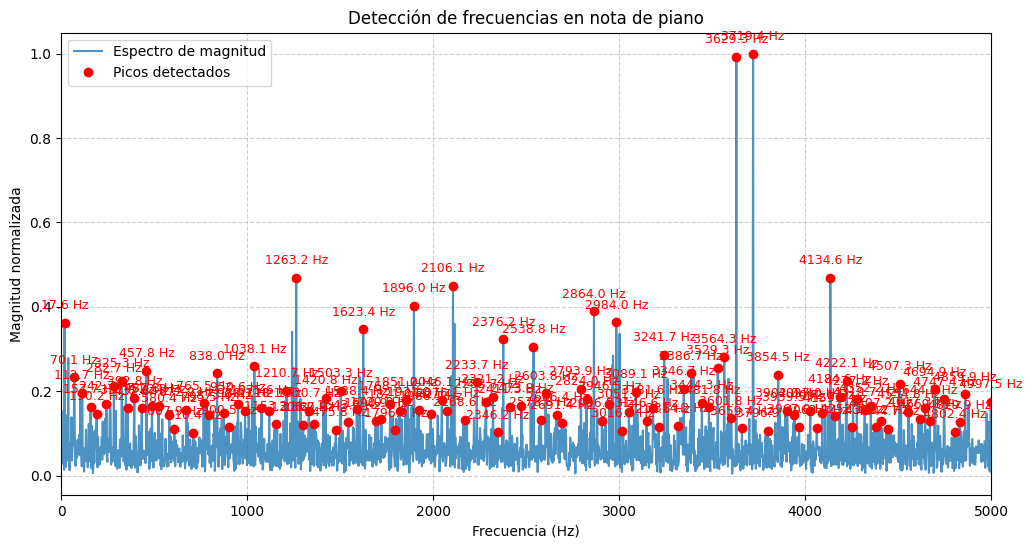

Frecuencias detectadas (Hz):
[17.60840420210105, 70.13361680840418, 112.65402701350673, 157.67563781890942, 190.19124562281138, 242.71645822911455, 282.735667833917, 325.25607803901954, 357.77168584292144, 392.78849424712354, 432.80770385192596, 457.81970985492745, 487.8341170585292, 522.8509254627314, 580.3785392696348, 607.8917458729364, 672.9229614807404, 710.4409704852426, 765.467383691846, 795.4817908954477, 838.0022011005502, 873.0190095047524, 900.532216108054, 950.5562281140569, 988.0742371185592, 1038.098249124562, 1075.6162581290644, 1118.1366683341669, 1153.1534767383691, 1210.6810905452724, 1263.2063031515756, 1300.724312156078, 1330.7387193596796, 1360.7531265632813, 1420.781940970485, 1475.8083541770884, 1503.32156078039, 1543.3407703851924, 1588.3623811905952, 1623.379189594797, 1690.9116058029012, 1720.9260130065031, 1768.448824412206, 1795.9620310155076, 1820.974037018509, 1850.9884442221107, 1896.0100550275135, 1921.022061030515, 1986.053276638319, 2046.0820910455225,

In [3]:
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate, integrate
from scipy.signal import find_peaks

# Base de Fourier continua
def g(t, w):
    return (1.0 / (2.0 * 3.141592653589793)) * complex(0, -1) * 0 + \
           (1.0 / (2.0 * 3.141592653589793)) * (
               __import__("cmath").exp(-1j * 2.0 * 3.141592653589793 * w * t)
           )

def FT(x, y, w_min=0.1, w_max=5000.0, n_w=4000):
    """
    Calcula una FT continua aproximada de la señal y(x) evaluando
    una grilla de frecuencias w. Devuelve un DataFrame.
    """

    # Interpolación de la señal
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    # Grilla de frecuencias
    w = [w_min + i * (w_max - w_min) / (n_w - 1) for i in range(n_w)]

    rows = []
    t0 = float(x[0])
    t1 = float(x[-1])

    for wi in w:
        re_part = integrate.quad(
            lambda t: (ft(t) * g(t, wi)).real,
            t0, t1
        )[0]

        im_part = integrate.quad(
            lambda t: (ft(t) * g(t, wi)).imag,
            t0, t1
        )[0]

        amp = (re_part**2 + im_part**2) ** 0.5
        ang = __import__("math").atan2(im_part, re_part)

        rows.append([wi, re_part, im_part, amp, ang])

    return pd.DataFrame(rows, columns=["w", "ReTw", "ImTw", "AMP", "ANG"])


# 1. Cargar audio
signal, sr = librosa.load(
    r"C:\Proyectos\Fisica-com\Fisica_Computacional_1\Sesiones\Fourier\Nota_CM_piano.mp3",
    sr=None
)

# 2. Construir eje temporal
N = len(signal)
t = [i / sr for i in range(N)]

# 3. Calcular transformada continua aproximada
df_ft = FT(t, signal, w_min=0.1, w_max=5000.0, n_w=2000)

# 4. Normalizar magnitud
max_amp = df_ft["AMP"].max()
df_ft["AMP_norm"] = df_ft["AMP"] / max_amp if max_amp != 0 else df_ft["AMP"]

# 5. Detectar picos
peaks, properties = find_peaks(df_ft["AMP_norm"], height=0.1, distance=10)

# 6. Visualización
plt.figure(figsize=(12, 6))
plt.plot(df_ft["w"], df_ft["AMP_norm"], label="Espectro de magnitud", alpha=0.8)
plt.plot(df_ft.loc[peaks, "w"], df_ft.loc[peaks, "AMP_norm"], "ro", label="Picos detectados")

for p in peaks:
    freq = df_ft.loc[p, "w"]
    amp = df_ft.loc[p, "AMP_norm"]
    plt.annotate(
        f"{freq:.1f} Hz",
        (freq, amp),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        color="red"
    )

plt.title("Detección de frecuencias en nota de piano")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud normalizada")
plt.xlim(0, 5000)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# 7. Imprimir frecuencias detectadas
print("Frecuencias detectadas (Hz):")
print(df_ft.loc[peaks, "w"].to_list())

Se obtiene un resultado muy distinto, dado con una gran cantidad de ruido.